# Customer Churn Prediction for Telecom Customer Retention

# 1.Business Understanding

## 1.1 Overview

The goal is to build a classification model that predicts customer churn. By identifying at-risk customers early, the business can reduce revenue loss and decrease the high marketing costs associated with acquiring new customers.

## 1.2 Stakeholders

#### Customer Retention & Marketing: 

To target at-risk customers with promotions.

#### Business Analysts & Management: 

To track churn trends and improve overall retention strategy.

## 1.3 Objective

To build a classification model that predicts customer churn using historical customer data.

## 1.4 Success Metrics

Recall is the primary success metric. Because the cost of losing a customer is significantly higher than the cost of an unnecessary discount, we prioritize identifying as many potential churners as possible.

## 1.5 Methodology

We will establish a Logistic Regression baseline and iterate toward a Tuned Decision Tree to maximize recall and identify key churn drivers.

## 1.6 Constraints

#### Data Gaps:

External factors (competitor pricing, network outages) are not captured in the dataset.

#### Class Imbalance: 

Churners typically represent a small fraction of the data, which may skew model performance.

## 2. Data Understanding

This section explores the dataset used for predicting customer churn. The goal is to understand the source, structure, and properties of the data, and evaluate how suitable it is for building a classification model to solve the business problem.

### 2.1. dataset

In [93]:
#1. confirming the path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
os.path.exists("../data/bigml_59c28831336c6604c800002a.csv")


True

In [94]:
# loading the dataset
df = pd.read_csv("../data/bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 2.2 Dataset Shape 

We check the number of rows and columns to understand the scale of the dataset.

In [95]:
# check shape
df.shape

(3333, 21)

### 2.3 Sammary Statistics

We generate summary statistics for numerical features to understand distributions and variability in the data.

In [96]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### 2.4 Exploratory data analysis

#### 2.4.1 Target variable Distribution

tareget distribution determines dataset imbalance and help choose correct evaluation metric

In [123]:
# Check churn balance (target variable distribution)
df['churn'].value_counts(normalize=True)

0    0.855086
1    0.144914
Name: churn, dtype: float64

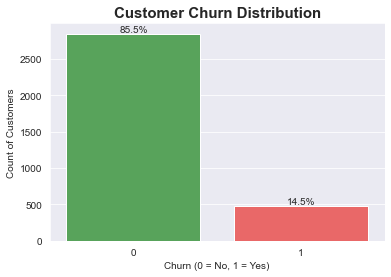

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='churn',
    data=df,
    palette=['#4CAF50', '#FF5252']  # green vs red
)

plt.title("Customer Churn Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count of Customers")

# add percentage labels
total = len(df)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        height + 20,
        f'{height/total:.1%}',
        ha="center"
    )

plt.show()

#### Insight

Dataset is highly imbalanced

Most customers do NOT churn (~85%)

Only a small portion churn (~15%)

#### 2.4.2 Customer Service Calls vs Churn

Customers who churn may have experienced more issues with the service, which is reflected in the number of times they contacted customer service. This helps us understand whether dissatisfaction contributes to churn.

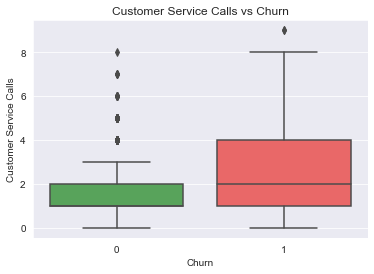

In [124]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='customer service calls',
    data=df,
    palette=['#4CAF50', '#FF5252']
)

plt.title("Customer Service Calls vs Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Service Calls")

plt.show()

#### Insight

Customers who churn tend to have more service calls

Suggests dissatisfaction or unresolved issues

### 2.4.3 Total Day Charge vs Churn

This section examines whether customers who pay higher charges during the day are more likely to churn. This helps determine if pricing is a factor in customer loss.

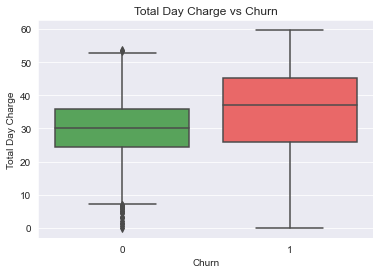

In [127]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='total day charge',
    data=df,
    palette=['#4CAF50', '#FF5252']
)

plt.title("Total Day Charge vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Day Charge")

plt.show()

#### Insight

Churned customers tend to have higher charges

Cost may be a driver of churn

### 2.5 Feature Justification

The features in this dataset are relevant for predicting churn because they represent customer usage patterns, service plans, and account behavior.

Examples include:
- Call usage (day, evening, night minutes)
- Service plans (international plan, voicemail plan)
- Account activity (customer service calls)

These features are useful because customer behavior and service engagement are strong indicators of whether a customer is likely to churn.

### 2.6 Data Limitations

Although the dataset is useful for churn prediction, it has some limitations:

- It does not include external business factors such as pricing changes or competitor influence
- It may not capture real-time behavioral changes
- Some features may be indirectly related to churn rather than causal
- There may be class imbalance, which can affect model performance

These limitations should be considered when interpreting model results.

## 3.Data preparation

### 3.1 introduction

## Data Preparation

In this section, we prepare the dataset for machine learning.

The goal is to transform the raw data into a clean and structured format suitable for building classification models. This includes:

- Handling irrelevant features
- Encoding categorical variables
- Splitting data into training and testing sets
- Scaling numerical features where necessary

These steps are essential to improve model performance and ensure reliable predictions.

### 3.2 Drop Irrelevant Columns

### Removing Irrelevant Features

Some columns do not contribute to predicting churn and may introduce noise into the model.

For example:
- `phone number` is unique for each customer and has no predictive value.

Some columns in the dataset do not contribute to predicting customer churn.
For example, phone numbers are unique identifiers and do not contain predictive information.
These are removed to improve model performance and reduce noise.

In [98]:
# Drop columns that are not useful for modeling
df = df.drop(columns=['phone number'], errors='ignore')

In [99]:
df['churn'].value_counts(dropna=False)

False    2850
True      483
Name: churn, dtype: int64

In [100]:
# final check of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   international plan      3333 non-null   object 
 4   voice mail plan         3333 non-null   object 
 5   number vmail messages   3333 non-null   int64  
 6   total day minutes       3333 non-null   float64
 7   total day calls         3333 non-null   int64  
 8   total day charge        3333 non-null   float64
 9   total eve minutes       3333 non-null   float64
 10  total eve calls         3333 non-null   int64  
 11  total eve charge        3333 non-null   float64
 12  total night minutes     3333 non-null   float64
 13  total night calls       3333 non-null   int64  
 14  total night charge      3333 non-null   

### 3.3 ENCODE TARGET VARIABLE

Machine learning models require numerical input.
The target variable "churn" is converted into binary format:

1 = Customer churned
0 = Customer did not churn

In [101]:
# Convert target variable into binary format
df['churn'] = df['churn'].astype(int)

# Confirming the distribution after encoding
print(df['churn'].value_counts())

0    2850
1     483
Name: churn, dtype: int64


### 3.4. ENCODE BINARY FEATURES

Some features contain categorical values such as "yes" and "no".
These are converted into numerical values so that machine learning models can process them.

In [102]:
# Convert binary categorical features into numeric format
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

# Check unique values before mapping to avoid creating NaNs
print(df['international plan'].unique())

[0 1]


### 3.5. Encode cartegorical variable

The "state" column contains multiple categories.
One-hot encoding is used to convert it into separate binary columns.
This prevents the model from assuming any ordinal relationship between states.

In [103]:
df = pd.get_dummies(df, columns=['state'], drop_first=True)

### 3.6. HANDLE MISSING VALUES

Missing values can negatively affect model performance.
In this dataset, any rows with missing values are removed to ensure clean training data.

In [104]:
df = df.dropna(subset=['churn'])

### 3.7. DEFINE FEATURES AND TARGET

The dataset is split into features (X) and target (y).

X contains all input variables used for prediction
y contains the churn outcome we want to predict

In [105]:
X = df.drop('churn', axis=1)
y = df['churn']

print(X.shape)
print(y.value_counts())

(3333, 68)
0    2850
1     483
Name: churn, dtype: int64


### 3.8. TRAIN-TEST SPLIT (NO DATA LEAKAGE)

The dataset is split into training and testing sets.
The training set is used to build the model, while the test set is used to evaluate performance on unseen data.
Stratification ensures the class distribution is preserved in both sets.

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

It is important to confirm that the data has been split correctly and that class distribution is balanced across training and testing sets.

In [107]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set shape: (2666, 68)
Test set shape: (667, 68)

Class distribution in training set:
0    0.855214
1    0.144786
Name: churn, dtype: float64


### 3.9 INSIGHT

The dataset was split into training (2666 rows) and testing (667 rows) sets using an 80/20 split with stratification to preserve the original class distribution.

The target variable shows a clear class imbalance, with approximately 85% of customers not churning and 15% churning.

This imbalance is important for modeling because it means that accuracy alone would not be a reliable evaluation metric. Instead, recall will be prioritized to ensure that potential churners are correctly identified, since failing to detect churners has a higher business cost.

## 4. MODELLING

In this section, we build classification models to predict customer churn.
We begin with a baseline model for interpretability, then improve performance using a decision tree and hyperparameter tuning.
The primary evaluation metric is Recall, since correctly identifying customers who are likely to churn is more important than overall accuracy.

### 4.1 FEATURE SCALING

Feature scaling is applied to ensure that all variables contribute equally to the model.
Logistic Regression performs better when numerical features are standardized.

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data (prevents data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

### 4.1 BASELINE MODEL (LOGISTIC REGRESSION)

Logistic Regression is used as a baseline model due to its simplicity and interpretability.

In [109]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [110]:
# EVALUATION CELL

from sklearn.metrics import classification_report, confusion_matrix, recall_score

print("=== Logistic Regression Results ===")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

=== Logistic Regression Results ===
[[550  20]
 [ 71  26]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       570
           1       0.57      0.27      0.36        97

    accuracy                           0.86       667
   macro avg       0.73      0.62      0.64       667
weighted avg       0.84      0.86      0.84       667

Recall: 0.26804123711340205


### 4.3 DECISION TREE MODEL

Decision Trees are non-parametric models that do not require feature scaling and can capture non-linear relationships.

In [111]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [112]:
# EVALUATION CELL
print("=== Decision Tree Results ===")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))

=== Decision Tree Results ===
[[541  29]
 [ 35  62]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       570
           1       0.68      0.64      0.66        97

    accuracy                           0.90       667
   macro avg       0.81      0.79      0.80       667
weighted avg       0.90      0.90      0.90       667

Recall: 0.6391752577319587


### 4.4 TUNED DECISION TREE

Hyperparameters are adjusted to improve generalization and reduce overfitting.

In [113]:
# cose cell for turned decision tree
tree_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

tree_tuned.fit(X_train, y_train)

y_pred_tuned = tree_tuned.predict(X_test)

In [114]:
print("=== Tuned Decision Tree Results ===")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))

=== Tuned Decision Tree Results ===
[[551  19]
 [ 36  61]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       570
           1       0.76      0.63      0.69        97

    accuracy                           0.92       667
   macro avg       0.85      0.80      0.82       667
weighted avg       0.91      0.92      0.91       667

Recall: 0.6288659793814433


## 5 MODEL EVALUATION

### 5.1 INTRODUCTION

In this section, we evaluate the performance of the classification models built to predict customer churn.
The evaluation focuses on multiple metrics, with Recall as the primary metric, since the business goal is to correctly identify customers who are likely to churn.
Missing a churner (false negative) is more costly than incorrectly flagging a non-churner.

  - the evaluation metrics used are;recall,precision,F1-score and accuracy

### 5.2 Model Comparison

We compare models using recall as the primary metric. This is because the business objective is to correctly identify customers who are likely to churn.

In [115]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

results = {
    "Logistic Regression": {
        "Recall": recall_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "F1": f1_score(y_test, y_pred_log),
        "Accuracy": accuracy_score(y_test, y_pred_log)
    },
    "Decision Tree": {
        "Recall": recall_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "F1": f1_score(y_test, y_pred_tree),
        "Accuracy": accuracy_score(y_test, y_pred_tree)
    },
    "Tuned Decision Tree": {
        "Recall": recall_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned),
        "F1": f1_score(y_test, y_pred_tuned),
        "Accuracy": accuracy_score(y_test, y_pred_tuned)
    }
}

import pandas as pd

pd.DataFrame(results).T

,Recall,Precision,F1,Accuracy
Logistic Regression,0.268041,0.565217,0.363636,0.863568
Decision Tree,0.639175,0.681319,0.659574,0.904048
Tuned Decision Tree,0.628866,0.762500,0.689266,0.917541


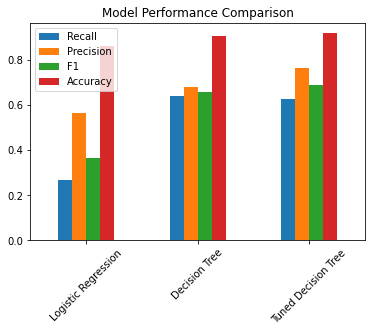

In [116]:
### plot on model comparison chart
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame(results).T

comparison[['Recall','Precision','F1','Accuracy']].plot(kind='bar')
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

### 5.3 CONFUSION MATRIX INSIGHT

The confusion matrix shows how well the model distinguishes between churners and non-churners.

True Negatives (TN): 551

→ Customers correctly predicted as not churned

False Positives (FP): 19

→ Customers incorrectly predicted to churn

False Negatives (FN): 36

→ Customers who actually churned but were missed by the model

True Positives (TP): 61

→ Customers correctly identified as churners

Reducing false negatives is the key priority for this business problem.

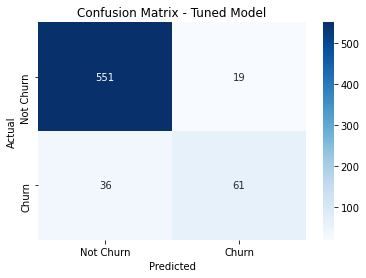

In [117]:
# confusion matrix analysis
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])

plt.title("Confusion Matrix - Tuned Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.5 BEST MODEL SELECTION

Based on evaluation results, the Tuned Decision Tree model provides the best balance of performance, particularly in terms of recall.
Although Logistic Regression is more interpretable, the tuned tree captures non-linear relationships better and improves churn detection.

## 6. Model interpretation

### 6.1 Feature importance

Feature importance analysis shows which variables most influence churn prediction.
The most influential features can guide business strategies for customer retention, such as improving service quality or addressing customer complaints.

In [118]:
# FEATURE IMPORTANCE
feature_importance.head(10)

,Feature,Importance
7,total day charge,0.194752
17,customer service calls,0.165136
5,total day minutes,0.126952
16,total intl charge,0.112344
2,international plan,0.092779
10,total eve charge,0.085532
15,total intl calls,0.082755
4,number vmail messages,0.068827
8,total eve minutes,0.031257
11,total night minutes,0.012293


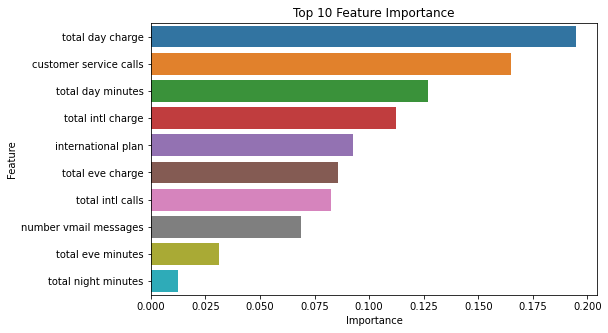

In [119]:
# plot on feature importance
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_features['Importance'], y=top_features['Feature'])
plt.title("Top 10 Feature Importance")
plt.show()

### 6.2 What drives churn

##### This section interprets the feature importance results from the tuned decision tree model in order to understand the key drivers of customer chur.  Feature importance allows us to identify which variables have the strongest influence on the model’s predictions. This helps translate the machine learning results into meaningful business insights.

#### Cost-related factors
(Total day charge, total evening charge, total international charge)
→ Customers with higher service costs are more likely to churn.
#### Customer service experience
(Customer service calls)
→ A high number of support calls indicates dissatisfaction and increases churn risk.
#### International service usage
(International plan, international charges, international calls)
→ Customers using international services show higher churn tendency due to higher costs.
#### High usage patterns
(Total day minutes, voicemail messages)
→ Heavy users may churn if pricing is not competitive or value is not perceived as fair.

## 7. LIMITATIONS

-The dataset is imbalanced, with far fewer churners than non-churners, which can affect model performance.

-The model does not incorporate external behavioral or financial data, which may improve prediction accuracy.

-Some misclassification of churners still occurs, meaning not all at-risk customers are captured.

### 8. FINAL BUSINESS INTERPRETATION

The model can help the business identify customers who are likely to churn, enabling proactive retention strategies such as targeted offers, improved customer support, or loyalty incentives.

By focusing on recall, the model prioritizes identifying as many churn-risk customers as possible, which reduces potential revenue loss.